In [ ]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True
# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")
# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\_aromatic_2025_581_CHINO.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
891,2-Iodo-N-(tetrahydro-furan-2-ylmethyl)-benzamide,C12H14INO2,331,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Ic1ccccc1C(=O)NCC2CCCO2,CHINO
2541,"4,6-Dihydroxy-5-nitro-2-(3-iodostyryl)pyrimidine",C12H8IN3O4,385,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Oc1nc(C=Cc2cccc(I)c2)nc(O)c1[N+]([O-])=O,CHINO
3677,"Benzoic acid, 4-iodo-2-(2-methyl-1-oxopropylam...",C11H12INO3,333,351424-01-6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)C(=O)Nc1cc(I)ccc1C(O)=O,CHINO
4970,"Acetamide, N-(4-iodophenyl)-2-(4-methyl-3-oxom...",C13H15IN2O3,374,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN1CCOC(CC(=O)Nc2ccc(I)cc2)C1=O,CHINO
8684,1-(4-Iodo-phenyl)-3-(4-methyl-piperidin-1-yl)-...,C16H19IN2O2,398,312281-52-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC1CCN(CC1)C2CC(=O)N(C2=O)c3ccc(I)cc3,CHINO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170466,"Acetamide, N-(4-iodophenyl)-2-(4-methyl-3-oxom...",C13H15IN2O3,374,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN1CCOC(CC(=O)Nc2ccc(I)cc2)C1=O,CHINO
174897,2-Iodo-N-(tetrahydro-furan-2-ylmethyl)-benzamide,C12H14INO2,331,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Ic1ccccc1C(=O)NCC2CCCO2,CHINO
176547,"4,6-Dihydroxy-5-nitro-2-(3-iodostyryl)pyrimidine",C12H8IN3O4,385,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Oc1nc(C=Cc2cccc(I)c2)nc(O)c1[N+]([O-])=O,CHINO
177683,"Benzoic acid, 4-iodo-2-(2-methyl-1-oxopropylam...",C11H12INO3,333,351424-01-6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)C(=O)Nc1cc(I)ccc1C(O)=O,CHINO


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(580), np.int64(600)), y.shape: (np.int64(580),), w.shape: (np.int64(580),), ids: [0 1 2 ... 577 578 579], task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[#N]': 3,
 '[/-Ring1]': 4,
 '[/C]': 5,
 '[/N]': 6,
 '[/O]': 7,
 '[=Branch1]': 8,
 '[=Branch2]': 9,
 '[=C]': 10,
 '[=N]': 11,
 '[=O]': 12,
 '[=Ring1]': 13,
 '[=Ring2]': 14,
 '[Branch1]': 15,
 '[Branch2]': 16,
 '[C@@H1]': 17,
 '[C@H1]': 18,
 '[C]': 19,
 '[I]': 20,
 '[N+1]': 21,
 '[NH1]': 22,
 '[N]': 23,
 '[O-1]': 24,
 '[O]': 25,
 '[P]': 26,
 '[Ring1]': 27,
 '[Ring2]': 28,
 '[S]': 29,
 '[\\-Ring1]': 30,
 '[\\C]': 31,
 '[\\N]': 32,
 '[nop]': 33}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 502
📦 Validation set size: 0
📦 Test set size: 78


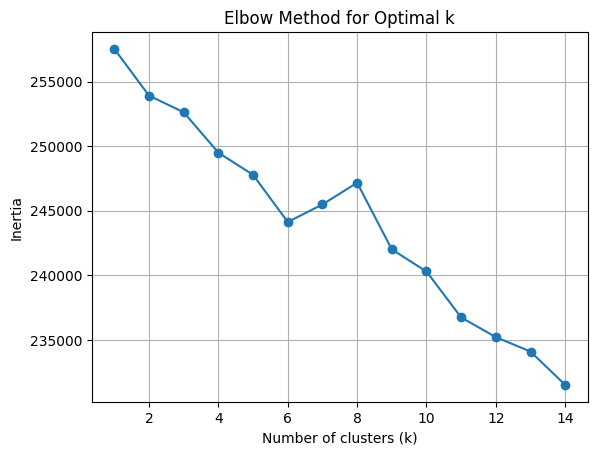

🔍 Elbow point detected at k = 6


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [9]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=2,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  m

In [10]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(2):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (99, 600)
Cluster 1 shape: (403, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  m

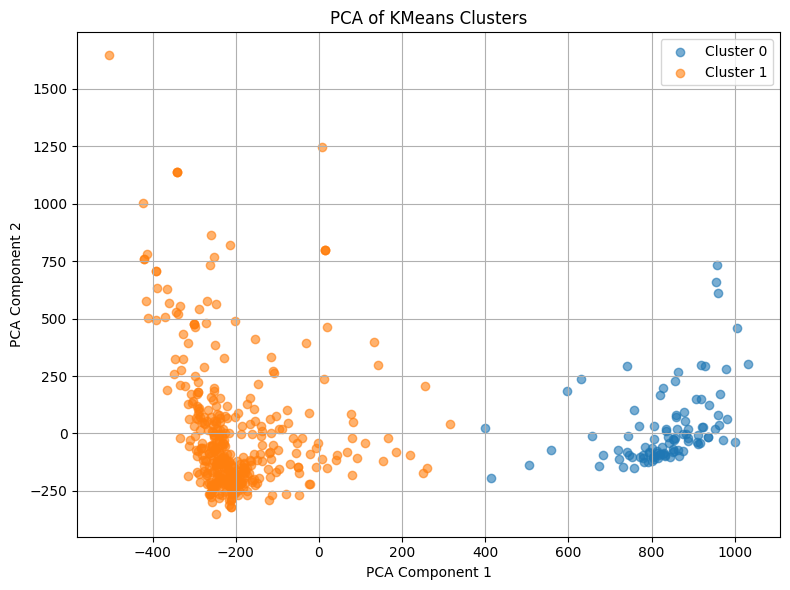

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=2)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [12]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [13]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indice

Cluster 0: size = 11, shape = (11, 600)
Cluster 1: size = 67, shape = (67, 600)


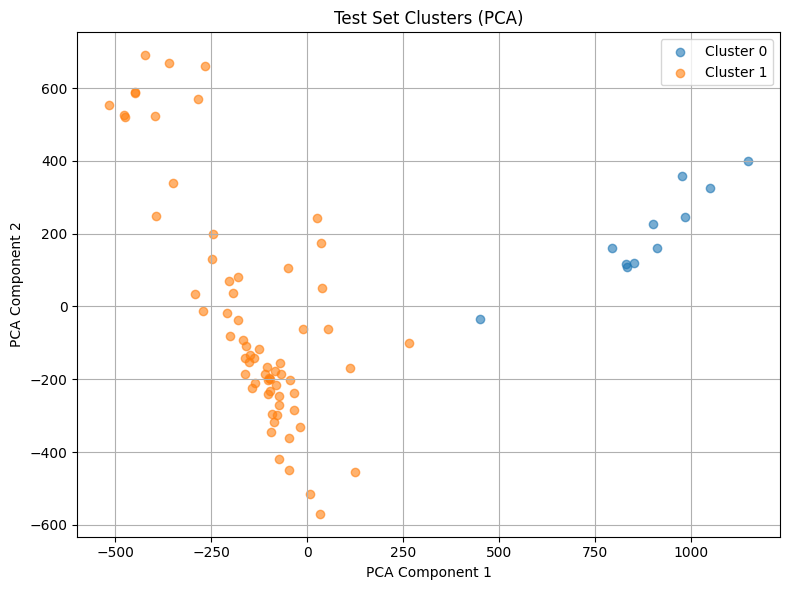

In [14]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(2):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 2.015190
Epoch 2/100 - Loss: 0.308633
Epoch 3/100 - Loss: 0.100047
Epoch 4/100 - Loss: 0.083300
Epoch 5/100 - Loss: 0.080596
Epoch 6/100 - Loss: 0.072851
Epoch 7/100 - Loss: 0.063247
Epoch 8/100 - Loss: 0.057196
Epoch 9/100 - Loss: 0.052032
Epoch 10/100 - Loss: 0.049038
Epoch 11/100 - Loss: 0.046641
Epoch 12/100 - Loss: 0.045206
Epoch 13/100 - Loss: 0.044436
Epoch 14/100 - Loss: 0.043810
Epoch 15/100 - Loss: 0.042710
Epoch 16/100 - Loss: 0.041742
Epoch 17/100 - Loss: 0.040512
Epoch 18/100 - Loss: 0.039932
Epoch 19/100 - Loss: 0.038957
Epoch 20/100 - Loss: 0.038008
Epoch 21/100 - Loss: 0.036863
Epoch 22/100 - Loss: 0.036088
Epoch 23/100 - Loss: 0.034877
Epoch 24/100 - Loss: 0.033455
Epoch 25/100 - Loss: 0.032329
Epoch 26/100 - Loss: 0.031018
Epoch 27/100 - Loss: 0.029553
Epoch 28/100 - Loss: 0.028526
Epoch 29/100 - Loss: 0.027535
Epoch 30/100 - Loss: 0.026281
Epoch 31/100 - Loss: 0.025522
Epoch 32/100 - Loss: 0.023976
Epoch 33/100 - Loss: 0.023096
Epoch 34/100 - Loss

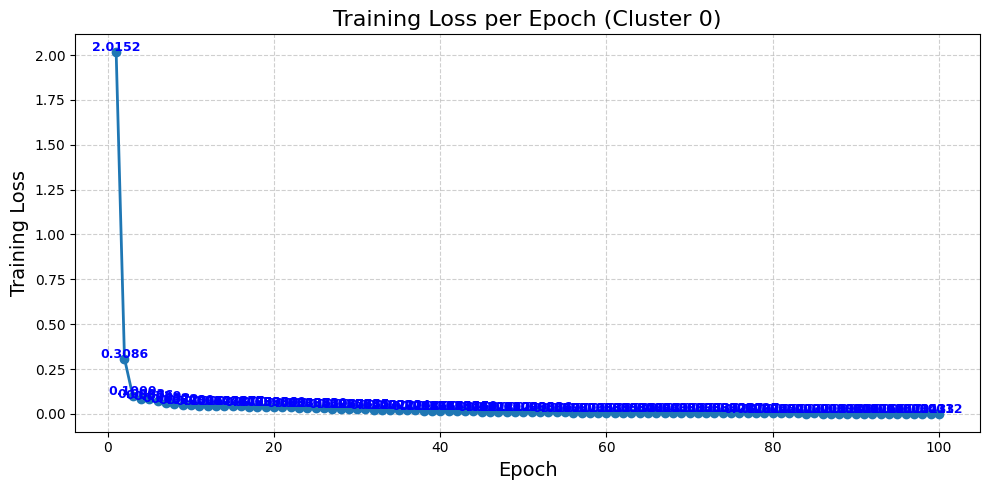

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\models_\model0000


In [15]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [16]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [17]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (11, 2108, 2)
Example prediction: [[1.0000000e+00 1.6024550e-11]
 [1.0000000e+00 7.4275692e-09]
 [1.0000000e+00 3.6910332e-11]
 ...
 [1.0000000e+00 9.8478115e-10]
 [1.0000000e+00 6.3862919e-09]
 [1.2472098e-08 1.0000000e+00]]


In [18]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [19]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [20]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CCCCC=C=CNC(=O)C=C(C)CI | True: COC1=CC=CC=C1C=C2N=C(OC2=O)C3=CC=C(I)C=C3 | Tanimoto: 0.093
[1] Pred: IC1=CC=CC(=C1)C(=O)NC2=CC=CC(=C23)COC=CCC=CN3 | True: IC1=CC=C(C=C1)C(=O)NC2=CC3=C(OC2=O)C=CC4=CC=CC=C34 | Tanimoto: 0.362
[2] Pred: CCCCNC(=O)CCC=CCC | True: IC1=CC=C(C=C1)C(=O)NC2CCCC2 | Tanimoto: 0.132
[3] Pred: NNC(=O)C=CC=CC=CI | True: NNC(=O)C1=CC=CC(I)=C1 | Tanimoto: 0.070
[4] Pred: CC(C)(C1)CC=C(C=C1)C=C2N=C(OC2=O)C3=CC=C(I)C=C3 | True: CC(C)(C)C1=CC=C(C=C1)C=C2N=C(OC2=O)C3=CC=CC(I)=C3 | Tanimoto: 0.521
[5] Pred: C(C)CC=CCCC=C | True: OC1=CC=C(C=NNC(=O)C2=CC=CC=C2I)C(O)=C1 | Tanimoto: 0.017
[6] Pred: CC(C)(C)NC(=O)C=CC=CC(I)=C | True: CC(C)(C)NC(=O)C1=CC=C(I)C=C1 | Tanimoto: 0.129
[7] Pred: CC(C)CCCCCC=CC=CC#C | True: CC1=NN(C(=O)C2=CC=C(I)C=C2)C(C)(O)C1 | Tanimoto: 0.044
[8] Pred: IC1=C2C=CC=C1C2C=O | True: IC1=CC=C(C=C1)C(=O)OC2=CC=CC3=CC=CN=C23 | Tanimoto: 0.173
[9] Pred: CCCCN(C)CC=CNC=CC1C=CC=C(C)C1 | True: CC(C)C1=CC=C(CNC(=O)C2=CC=CC=C2I)C=C1 | Tanimoto: 0.066


Epoch 1/100 - Loss: 0.522607
Epoch 2/100 - Loss: 0.065524
Epoch 3/100 - Loss: 0.049934
Epoch 4/100 - Loss: 0.045441
Epoch 5/100 - Loss: 0.042632
Epoch 6/100 - Loss: 0.040471
Epoch 7/100 - Loss: 0.038981
Epoch 8/100 - Loss: 0.037455
Epoch 9/100 - Loss: 0.035882
Epoch 10/100 - Loss: 0.034111
Epoch 11/100 - Loss: 0.032337
Epoch 12/100 - Loss: 0.030468
Epoch 13/100 - Loss: 0.028417
Epoch 14/100 - Loss: 0.026524
Epoch 15/100 - Loss: 0.024585
Epoch 16/100 - Loss: 0.022744
Epoch 17/100 - Loss: 0.021146
Epoch 18/100 - Loss: 0.019438
Epoch 19/100 - Loss: 0.017688
Epoch 20/100 - Loss: 0.016361
Epoch 21/100 - Loss: 0.014899
Epoch 22/100 - Loss: 0.014004
Epoch 23/100 - Loss: 0.012532
Epoch 24/100 - Loss: 0.011509
Epoch 25/100 - Loss: 0.010515
Epoch 26/100 - Loss: 0.009692
Epoch 27/100 - Loss: 0.008854
Epoch 28/100 - Loss: 0.008222
Epoch 29/100 - Loss: 0.007452
Epoch 30/100 - Loss: 0.006919
Epoch 31/100 - Loss: 0.006680
Epoch 32/100 - Loss: 0.005857
Epoch 33/100 - Loss: 0.005756
Epoch 34/100 - Loss

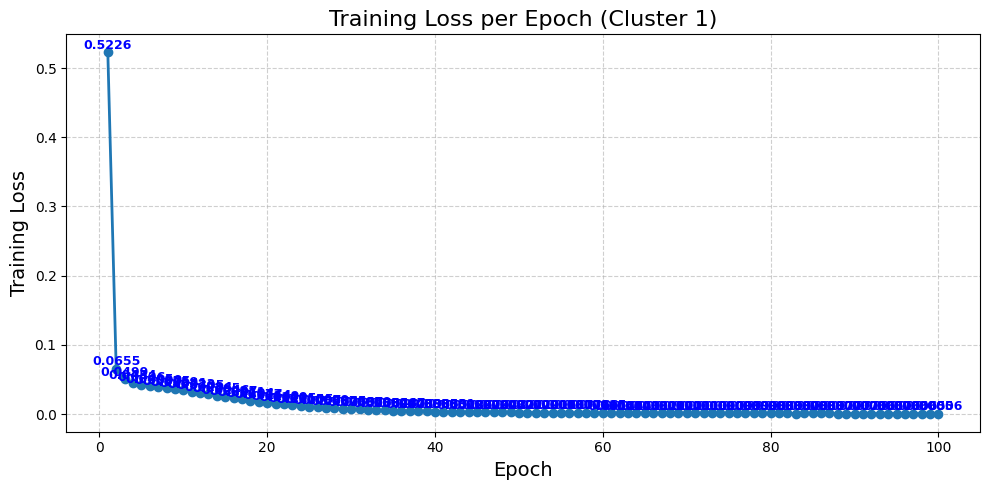

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with seed 123\models_\model1111


In [21]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [22]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_581_CHINO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (67, 2108, 2)
Example prediction: [[1.0000000e+00 1.1874469e-09]
 [1.0000000e+00 2.0228532e-09]
 [1.0000000e+00 3.8029149e-11]
 ...
 [1.0000000e+00 2.8079407e-08]
 [1.0000000e+00 1.6584206e-10]
 [5.6394665e-08 1.0000000e+00]]
[0] Pred: CC(C)(O)C=CCCI | True: CC(=O)N1C=C(I)C(=O)N(C(C)=O)C1=O | Tanimoto: 0.034
[1] Pred: CC(=O)OC=CN(C(C)=O)C=CC(I)C#C | True: CC(=O)OCC1OC(C(OC(C)=O)C1OC(C)=O)N2C=C(I)C(=O)NC2=O | Tanimoto: 0.138
[2] Pred: CCCCCC=O | True: CC(C)COC(=O)NC1=CC=CC=C1I | Tanimoto: 0.020
[3] Pred: NC1=NON=C1I | True: NC1=NON=C1I | Tanimoto: 1.000
[4] Pred: OC1=CC=C(I)C=C1C=NNC2=NC(NC3=CC=C(C=C3)[N+1]([O-1])=O)=NC(=N2)N4CCCCC4 | True: OC1=CC=C(I)C=C1C=NNC2=NC(NC3=CC=C(C=C3)[N+1]([O-1])=O)=NC(=N2)N4CCCCC4 | Tanimoto: 1.000
[5] Pred: [O-1][N+1](=O)C=1C=CN(CC(=O)NC2=CC=C(I)C=C2)N=1 | True: [O-1][N+1](=O)C=1C=CN(CC(=O)NC2=CC=C(I)C=C2)N=1 | Tanimoto: 1.000
[6] Pred: IC=1OC(=CC=1)C=NNC(=O)C2=CC=CC=N2 | True: IC=1OC(=CC=1)C=NNC(=O)C2=CC=CC=N2 | Tanimoto: 1.000
[7] Pre